# Netflix Data Analysis and Visualization Project

## Introduction
This notebook performs a comprehensive Exploratory Data Analysis (EDA) on a Netflix dataset. The goal is to uncover trends in content creation, understand distribution across countries, and categorize content for better insights.

### Steps covered:
1. **Data Cleaning:** Handling missing values and duplicates.
2. **Feature Engineering:** Creating new metrics like `year_added`, `cast_count`, and `rating_category`.
3. **Exploratory Analysis:** Statistical summaries and visual inspections.

## 1. Environment Setup and Data Loading
In this section, we import the necessary libraries for data manipulation (`pandas`, `numpy`) and visualization (`seaborn`, `matplotlib`). We also load the raw Netflix dataset.

In [412]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from warnings import filterwarnings
filterwarnings("ignore")



df = pd.read_csv("dataset/Netflix.csv")

## 2. Initial Data Inspection
Before cleaning, we take a quick look at the first few rows of the data, its dimensions, and the data types of each column to identify potential issues.

In [413]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [414]:
df.shape

(7787, 12)

In [415]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   int64 
 10  genres        7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(2), object(10)
memory usage: 730.2+ KB


In [416]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [417]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [418]:
df.duplicated().sum()

np.int64(0)

## 3. Data Cleaning
To ensure the quality of our analysis, we perform the following:
* **Drop Unnecessary Columns:** Removing `show_id` as it serves only as a unique identifier.
* **Impute Missing Values:** Filling gaps in `director`, `cast`, and `country` with "Unknown", and using the mode for `rating` and `date_added`.

In [419]:
df.drop(columns=['show_id'], inplace=True)

In [420]:
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna(df['rating'].mode()[0], inplace=True)
df['date_added'].fillna(df['date_added'].mode()[0], inplace=True)

## 4. Feature Engineering
We create new features to extract more value from the existing data:
1. **Date Extraction:** Converting `date_added` to datetime objects to extract year and month.
2. **Complexity Metrics:** Calculating the number of cast members and genres per title.
3. **Categorization:** Simplifying the content ratings into broader categories: **Adult**, **Teen**, and **Kids**.
4. **Localization:** Extracting the primary country of origin from the `country` column.

In [421]:
df['date_added'] = pd.to_datetime(df['date_added'])

df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [422]:
df.drop(columns=['date_added'], inplace=True)

In [423]:
df['cast_count'] = df['cast'].apply(lambda x: len(x.split(',')))
df['genre_count'] = df['genres'].apply(lambda x: len(x.split(',')))

In [424]:
df['duration_type'] = df['type']

df.rename(columns={'duration':'duration_value'}, inplace=True)

In [425]:
df['country_main'] = df['country'].apply(lambda x: x.split(',')[0])

In [426]:
def simplify_rating(r):
    if r in ['TV-MA','R','NC-17']:
        return "Adult"
    elif r in ['PG-13','TV-14']:
        return "Teen"
    else:
        return "Kids"

df['rating_category'] = df['rating'].apply(simplify_rating)

In [427]:
df.drop(columns=['rating'], inplace=True)

## 5. Exploratory Data Analysis & Visualization
With the data cleaned and enriched, we now move to the visualization phase. This help us identify:
* The distribution of content types (Movies vs. TV Shows).
* Trends in content releases over the years.
* Relationship between content duration and its category.

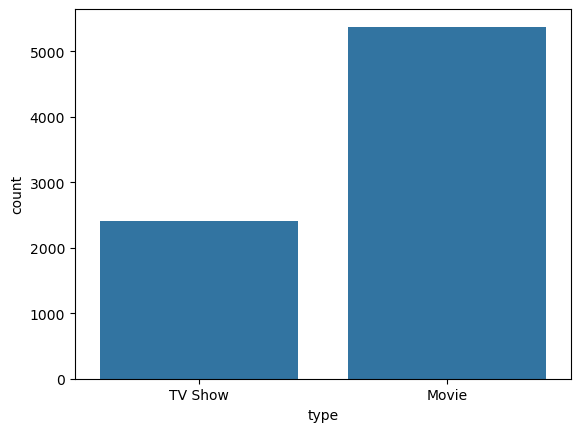

In [428]:
sns.countplot(x="type",data=df)
plt.show()

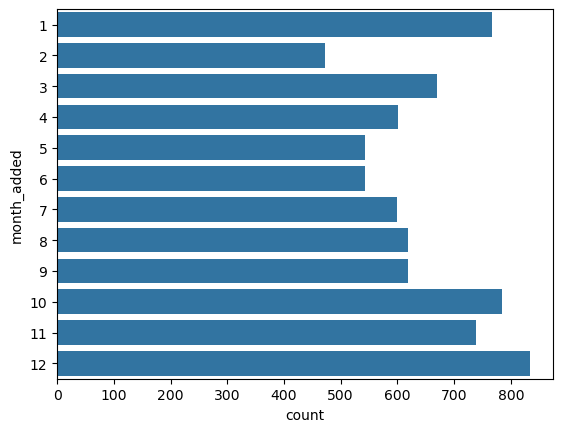

In [429]:
sns.countplot(y="month_added",data=df)
plt.show()

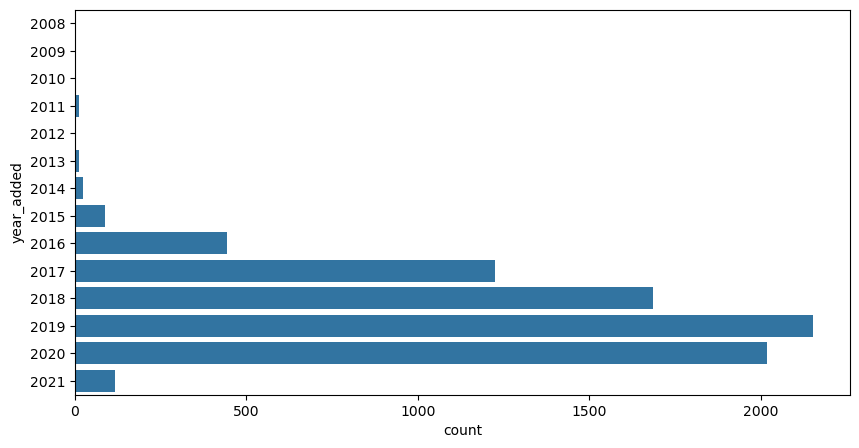

In [430]:
plt.figure(figsize=(10,5))
sns.countplot(y=df["year_added"])
plt.show()

In [431]:
df['has_director'] = df['director'].apply(lambda x: 0 if x=='Unknown' else 1)

<Axes: xlabel='duration_value', ylabel='Density'>

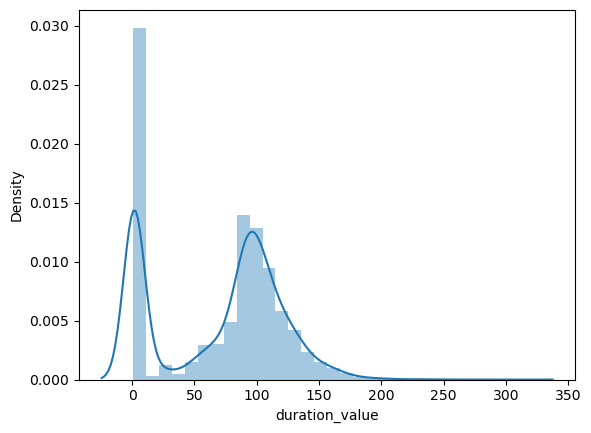

In [432]:
sns.distplot(df["duration_value"])

In [433]:
df.corr(numeric_only=True)["duration_value"].reset_index()

,index,duration_value
0,release_year,-0.240836
1,duration_value,1.000000
2,year_added,0.037102
3,month_added,-0.024913
4,cast_count,0.096601
5,genre_count,0.092256
6,has_director,0.820335


In [434]:
df.corr(numeric_only=True)

,release_year,duration_value,year_added,month_added,cast_count,genre_count,has_director
release_year,1.000000,-0.240836,0.100115,-0.009661,-0.086585,-0.052931,-0.166603
duration_value,-0.240836,1.000000,0.037102,-0.024913,0.096601,0.092256,0.820335
year_added,0.100115,0.037102,1.000000,-0.135006,0.113470,0.060552,-0.001745
month_added,-0.009661,-0.024913,-0.135006,1.000000,0.001902,-0.002332,-0.028360
cast_count,-0.086585,0.096601,0.113470,0.001902,1.000000,0.219182,0.008707
genre_count,-0.052931,0.092256,0.060552,-0.002332,0.219182,1.000000,-0.041000
has_director,-0.166603,0.820335,-0.001745,-0.028360,0.008707,-0.041000,1.000000


<Axes: >

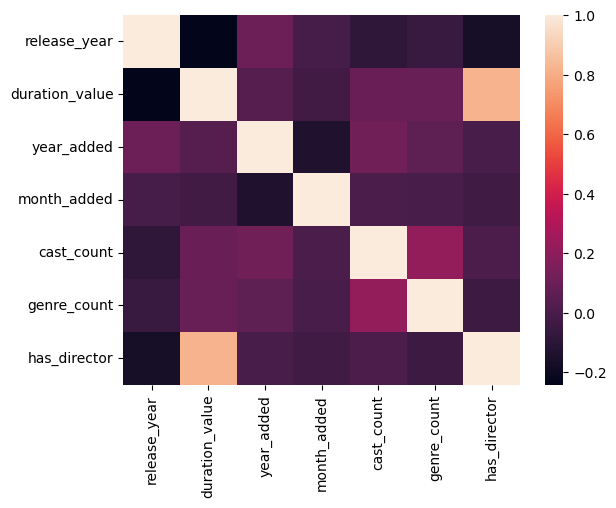

In [435]:
sns.heatmap(df.corr(numeric_only=True))

## Q1] CONTENT-TYPE LABELER:

In [436]:
df.head()

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,month_added,cast_count,genre_count,duration_type,country_main,rating_category,has_director
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,11,3,TV Show,Brazil,Adult,0
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,12,8,3,Movie,India,Adult,1
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,1,4,3,Movie,Indonesia,Kids,1
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,3,11,1,Movie,United States,Adult,1
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,12,1,3,TV Show,United Kingdom,Kids,0


### LOGISTIC - REGRESSION:

In [437]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle


num_features = ['cast_count', 'genre_count', 'duration_value']

cat_features = ['country_main', 'rating_category']

X = df[num_features + cat_features]
y = df['type']

# Split the data into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


num_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])


cat_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])



prediction_pipeline_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])


prediction_pipeline_1.fit(X_train, y_train)


y_pred = prediction_pipeline_1.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the pipeline model (similar to laptop project)
with open('netflix_type_predictor_pipeline_1.pkl', 'wb') as f:
    pickle.dump(prediction_pipeline_1, f)


# Example prediction function (like app.py in laptop project)
def predict_content_type(cast_count, genre_count, duration_value,
                         country_main, rating_category):
    # Create input DataFrame
    query_df = pd.DataFrame({
        'cast_count': [cast_count],
        'genre_count': [genre_count],
        'duration_value': [duration_value],
        'country_main': [country_main],
        'rating_category': [rating_category]
    })
    
    # Load the pipeline
    with open('netflix_type_predictor_pipeline_1.pkl', 'rb') as f:
        pipe = pickle.load(f)
    
    # Predict
    prediction = pipe.predict(query_df)[0]
    content_type = 'TV Show' if prediction == 1 else 'Movie'
    probability = pipe.predict_proba(query_df)[0]
    conf_movie = probability[0] * 100
    conf_tv = probability[1] * 100
    
    return f"Predicted Type: {content_type} (Confidence: {max(conf_movie, conf_tv):.2f}%)"

# Example usage
print("\nExample Prediction:")
result = predict_content_type(cast_count=8, genre_count=3, duration_value=143,
    country_main='India', rating_category='Adult'
)
print(result)

Accuracy: 0.9961

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      0.99      1.00      1076
     TV Show       0.99      1.00      0.99       482

    accuracy                           1.00      1558
   macro avg       0.99      1.00      1.00      1558
weighted avg       1.00      1.00      1.00      1558


Confusion Matrix:
[[1070    6]
 [   0  482]]

Example Prediction:
Predicted Type: Movie (Confidence: 100.00%)


### NAIVE - BAYES (Bernoulli) :

In [438]:
from sklearn.naive_bayes import BernoulliNB

prediction_pipeline_2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', BernoulliNB(
    alpha=1.0,
    binarize=0.0,
    fit_prior=True,
    class_prior=None
))
])


prediction_pipeline_2.fit(X_train, y_train)


y_pred = prediction_pipeline_2.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the pipeline model (similar to laptop project)
with open('netflix_type_predictor_pipeline_2.pkl', 'wb') as f:
    pickle.dump(prediction_pipeline_2, f)

Accuracy: 0.8954

Classification Report:
              precision    recall  f1-score   support

       Movie       0.98      0.86      0.92      1076
     TV Show       0.76      0.96      0.85       482

    accuracy                           0.90      1558
   macro avg       0.87      0.91      0.89      1558
weighted avg       0.91      0.90      0.90      1558


Confusion Matrix:
[[930 146]
 [ 17 465]]


### KNN:

In [439]:
from sklearn.neighbors import KNeighborsClassifier

prediction_pipeline_3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        weights='uniform',
        algorithm='auto',
        metric='minkowski',
        p=2
    ))
])

prediction_pipeline_3.fit(X_train, y_train)

y_pred = prediction_pipeline_3.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Movie', 'TV Show']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Save the pipeline model
with open('netflix_type_predictor_knn_pipeline_3.pkl', 'wb') as f:
    pickle.dump(prediction_pipeline_3, f)

Accuracy: 0.9891

Classification Report:
              precision    recall  f1-score   support

       Movie       1.00      0.99      0.99      1076
     TV Show       0.97      1.00      0.98       482

    accuracy                           0.99      1558
   macro avg       0.98      0.99      0.99      1558
weighted avg       0.99      0.99      0.99      1558


Confusion Matrix:
[[1060   16]
 [   1  481]]


## **CONCLUSION:** Highest accuracy is acheived through Logistic Regression.

## Q2] Can we build a machine learning model that predicts whether a piece of content should be produced as a Movie or a TV Show based on features like cast-size, country, and release trends?

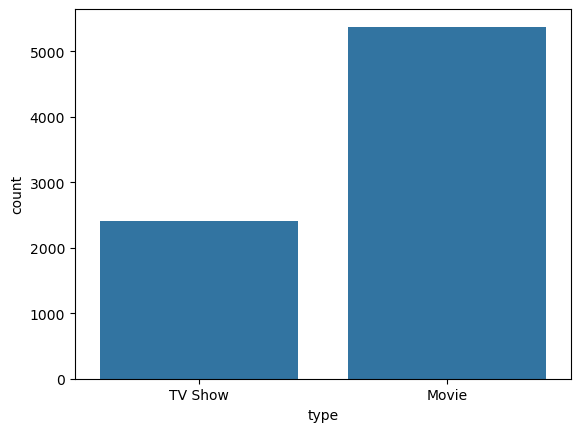

In [440]:
sns.countplot(x=df["type"])
plt.show()

In [441]:
data = df.groupby("type")["genre_count"].sum().reset_index()
data

,type,genre_count
0,Movie,11546
1,TV Show,5525


In [442]:
data = df.groupby("type")["cast_count"].sum().reset_index()
data

,type,cast_count
0,Movie,38738
1,TV Show,17935


<Axes: xlabel='release_year', ylabel='count'>

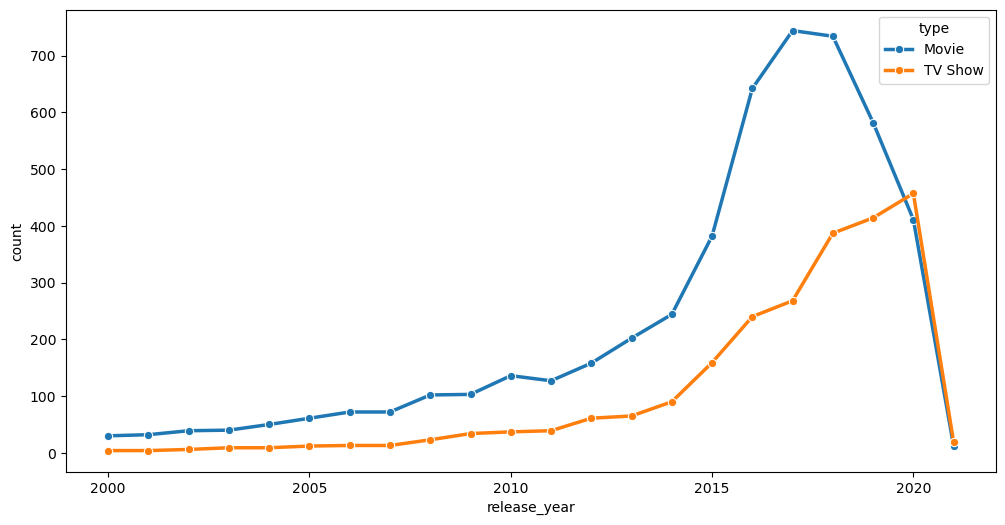

In [443]:
trend_data = df.groupby(['release_year', 'type']).size().reset_index(name='count')

trend_data_recent = trend_data[trend_data['release_year'] >= 2000]

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_data_recent, x='release_year', y='count', hue='type', marker='o', linewidth=2.5)

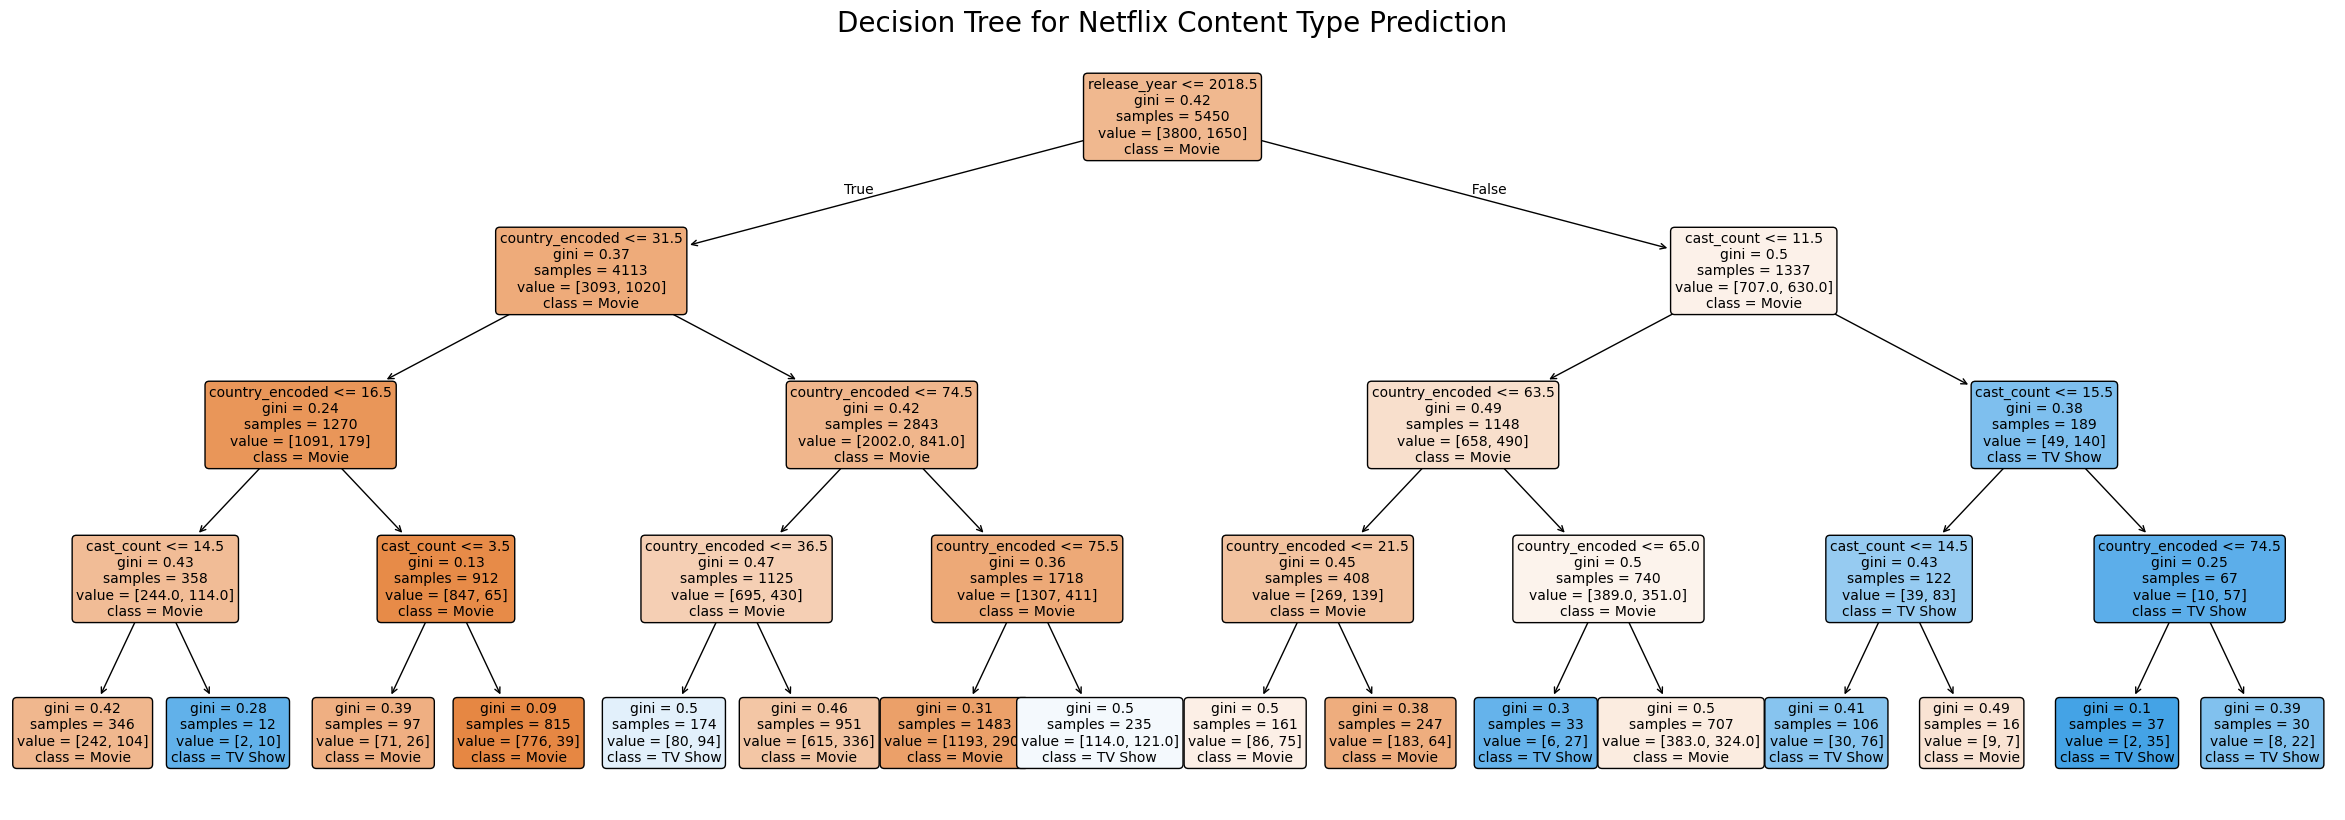

Accuracy: 0.7064612751390672


In [444]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# 1. Preprocessing categorical features
# We extract the first country and first genre to simplify the categories
df['first_country'] = df['country'].fillna('Unknown').apply (lambda x: x.split(',')[0])

# 2. Encode strings to numbers
le_country = LabelEncoder()

df['country_encoded'] = le_country.fit_transform(df['first_country'])



feature_cols = ["cast_count", "country_encoded", "release_year"]
X = df[feature_cols]
y = df["type"]


X_train , X_test , y_train, y_test = train_test_split(X,y, test_size=0.3,random_state=42)


model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train , y_train)


plt.figure(figsize=(30,10))
plot_tree(model, 
          feature_names=feature_cols, 
          class_names=["Movie", "TV Show"], 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          precision=2)

plt.title("Decision Tree for Netflix Content Type Prediction", fontsize=20)
plt.show()


print("Accuracy:",model.score(X_test, y_test))

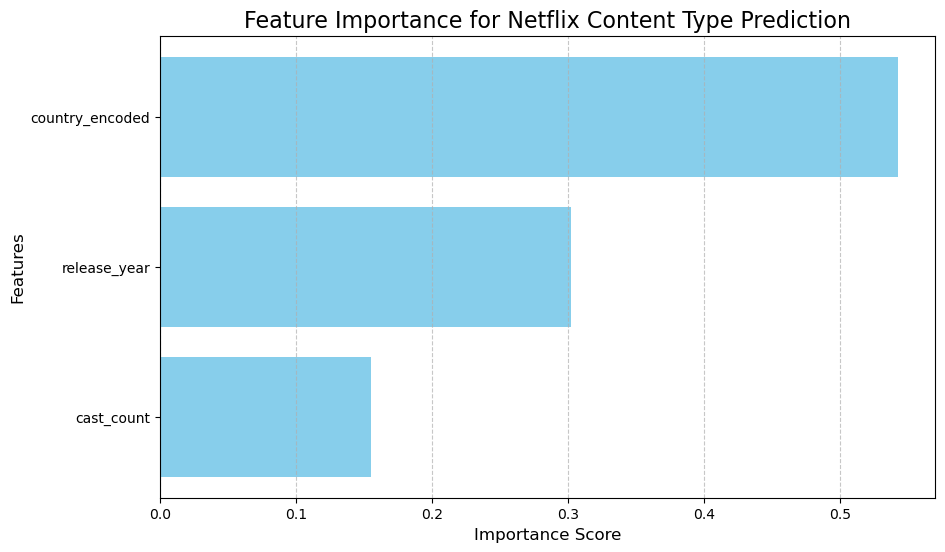

,index,Feature,Importance
0,0,country_encoded,0.542345
1,1,release_year,0.302328
2,2,cast_count,0.155326


In [445]:


# 1. Create a DataFrame to hold the feature names and their corresponding importance scores
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

# 2. Plot the Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')

plt.title('Feature Importance for Netflix Content Type Prediction', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

# 3. Print the values for reference
# Create the sorted dataframe and drop the old index
importance_display = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Display the clean table
importance_display.reset_index()

## Q3] Which countries dominate Netflix content, and how does the Movie vs TV-Show ratio change across the top 10 countries?

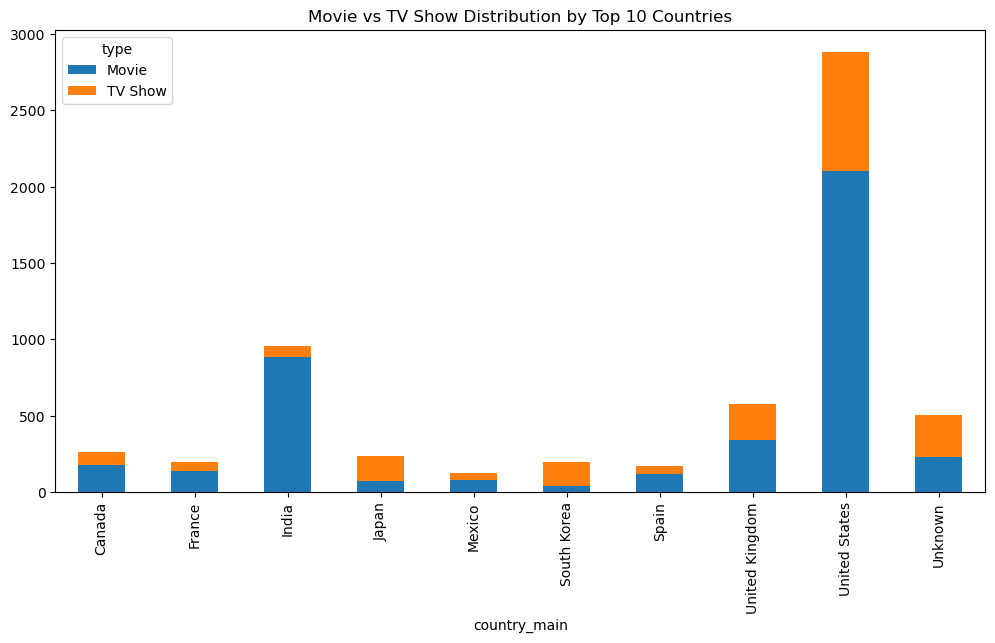

In [446]:
top10_countries = df['country_main'].value_counts().head(10).index
country_type = df[df['country_main'].isin(top10_countries)].groupby(['country_main', 'type']).size().unstack()
country_type.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Movie vs TV Show Distribution by Top 10 Countries')
plt.show()

## Q4] Do titles with a known director have significantly higher cast_count, genre_count, or longer duration than “Unknown” director titles?

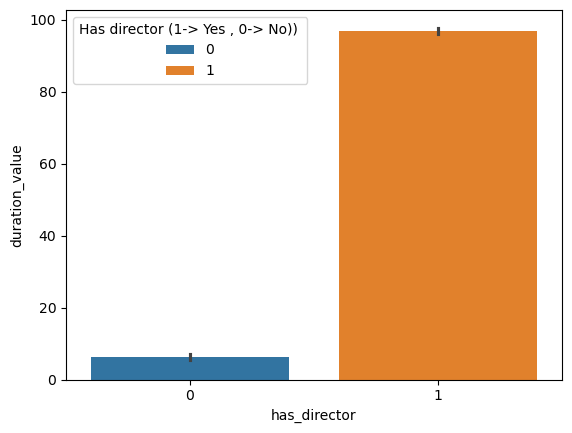

In [447]:
df.groupby('has_director')[['cast_count', 'genre_count', 'duration_value']].mean().round(2)
sns.barplot(x='has_director', y='duration_value',hue="has_director", data=df)
plt.legend(title="Has director (1-> Yes , 0-> No)) ")
plt.show()

In [448]:
df.head()

,type,title,director,cast,country,release_year,duration_value,genres,description,year_added,month_added,cast_count,genre_count,duration_type,country_main,rating_category,has_director,first_country,country_encoded
0,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,11,3,TV Show,Brazil,Adult,0,Brazil,6
1,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2008,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017,12,8,3,Movie,India,Adult,1,India,28
2,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2016,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019,1,4,3,Movie,Indonesia,Kids,1,Indonesia,29
3,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016,3,11,1,Movie,United States,Adult,1,United States,75
4,TV Show,Blue Planet II,Unknown,David Attenborough,United Kingdom,2017,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018,12,1,3,TV Show,United Kingdom,Kids,0,United Kingdom,74


### CONTENT- RECOMMENDATION SYSTEM:

In [449]:
import pandas as pd
import pickle

from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity


ps = PorterStemmer()

def stem(text):
    y = [ps.stem(i) for i in text.split()]
    return " ".join(y)


new_df = df[['title']].copy()

new_df["title"] = new_df["title"].apply(stem)


cv = CountVectorizer(max_features=5000, stop_words="english")

vectors = cv.fit_transform(new_df["title"]).toarray()

class RecommendationModel:

    def __init__(self, cv, vectors, df):
        self.cv = cv
        self.vectors = vectors
        self.df = df

    def recommend(self, content):

        stemmed_content = stem(content.lower())

        new_vector = self.cv.transform([stemmed_content]).toarray()

        distances = cosine_similarity(new_vector, self.vectors)[0]

        content_list = sorted(
            list(enumerate(distances)),
            reverse=True,
            key=lambda x: x[1]
        )[1:11] #recommend 10 movies

        print(f"\n\n\nRecommendations similar to: **{content}**\n")

        counter = 1
        
        for i in content_list:
            original_title = self.df.iloc[i[0]]['title']
            print(counter,")",f"• {original_title}")
            counter = counter+1


model = RecommendationModel(cv, vectors, df)



with open("content_recommendation_model.pkl", "wb") as f:
    pickle.dump(model, f)


with open("content_recommendation_model.pkl", "rb") as f:
    loaded_model = pickle.load(f)


loaded_model.recommend("Kesari 2")
loaded_model.recommend("Dune")
loaded_model.recommend("Stranger Things")
loaded_model.recommend("Article 15")
loaded_model.recommend("Dhurandhar")
loaded_model.recommend("Dhurandhar - The Revenge")
loaded_model.recommend("Dear Zindagi")




Recommendations similar to: **Kesari 2**

1 ) • 1920
2 ) • 3 Heroines
3 ) • Blue Mountain State: The Rise of Thadland
4 ) • Blue Planet II
5 ) • Blue Ruin
6 ) • Blue Streak
7 ) • Blue Valentine
8 ) • BluffMaster!
9 ) • Blurred Lines: Inside the Art World
10 ) • BNA



Recommendations similar to: **Dune**

1 ) • 1920
2 ) • 3 Heroines
3 ) • Blue Mountain State: The Rise of Thadland
4 ) • Blue Planet II
5 ) • Blue Ruin
6 ) • Blue Streak
7 ) • Blue Valentine
8 ) • BluffMaster!
9 ) • Blurred Lines: Inside the Art World
10 ) • BNA



Recommendations similar to: **Stranger Things**

1 ) • Beyond Stranger Things
2 ) • One Last Thing
3 ) • Stranger
4 ) • That Thing Called Tadhana
5 ) • THE STRANGER
6 ) • Cities of Last Things
7 ) • Little Things
8 ) • Most Beautiful Thing
9 ) • Perfect Stranger
10 ) • Archibald's Next Big Thing



Recommendations similar to: **Article 15**

1 ) • Article 15
2 ) • Kalel, 15
3 ) • 3%
4 ) • 1920
5 ) • 3 Heroines
6 ) • Blue Mountain State: The Rise of Thadland
7